In [3]:
import os
import glob
import numpy as np
import cv2
import yaml
import torch
from torch.utils.data import Dataset, DataLoader
from ultralytics import YOLO
from skimage import morphology, measure
import albumentations as A
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import time

In [7]:
train_image_path = os.path.join("..", "data", "train", "img")
val_image_path = os.path.join("..", "data", "val", "img")
test_image_path = os.path.join("..", "data", "test", "img")
train_mask_path = os.path.join("..", "data", "train", "mask")
val_mask_path = os.path.join("..", "data", "val", "mask")
test_mask_path = os.path.join("..", "data", "test", "mask")


In [8]:
train_image_files = sorted(glob.glob(os.path.join(train_image_path, "*.tif")))
train_mask_files = sorted(glob.glob(os.path.join(train_mask_path, "*.tif")))
val_image_files = sorted(glob.glob(os.path.join(val_image_path, "*.tif")))
val_mask_files = sorted(glob.glob(os.path.join(val_mask_path,"*.tif")))
test_image_files = sorted(glob.glob(os.path.join(test_image_path, "*.tif")))
test_mask_files = sorted(glob.glob(os.path.join(test_mask_path,"*.tif")))


In [9]:
print(f"Training images: {len(train_image_files)}")
print(f"Validation images: {len(val_image_files)}")
print(f"Test images: {len(test_image_files)}")


Training images: 32
Validation images: 3
Test images: 3


In [185]:
class TreeDetectionDataset(Dataset):
    def __init__(self, img_files, mask_files, augment=False, img_size=640, augment_factor=50):
        self.img_files = img_files
        self.mask_files = mask_files
        self.img_size = img_size
        self.augment = augment
        self.augment_factor = augment_factor if augment else 1

        # Define augmentation pipeline
        self.transform = self.get_transforms()
    def get_transforms(self):
        normalize = A.Normalize(mean=(0.3930, 0.4147, 0.4198, 0.5387),
                            std=(0.1011, 0.1138, 0.1334, 0.1320))

        if self.augment:
            return A.Compose([
                    A.RandomCrop(width=800, height=800, p=0.5),
                    A.Resize(self.img_size, self.img_size),
                    A.HorizontalFlip(p=0.5),
                    A.VerticalFlip(p=0.3),
                    A.RandomRotate90(p=0.5),
                    A.RandomBrightnessContrast(p=0.3),
                    A.GaussNoise(p=0.2),
                    # A.OneOf([
                    #     A.MotionBlur(p=0.2),
                    #     A.MedianBlur(blur_limit=3, p=0.1),
                    #     A.Blur(blur_limit=3, p=0.1),
                    # ], p=0.3),
                    # A.Normalize(mean=(0.39303034, 0.41469886, 0.41980474, 0.53865225), std=(0.10108781, 0.11376915, 0.13339881, 0.13201409)),
                ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))
        else:
            return A.Compose([
                A.Resize(self.img_size, self.img_size),
                #A.Normalize(mean=(0.39303034, 0.41469886, 0.41980474, 0.53865225), std=(0.10108781, 0.11376915, 0.13339881, 0.13201409))
            ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))


    def __len__(self):
        return len(self.img_files) * self.augment_factor

    def process_mask(self, mask):
        binary_mask = mask.copy()
        binary_mask = morphology.binary_erosion(binary_mask, footprint=np.ones((6,6)))
        return binary_mask

    def extract_bbox(self, mask):
        binary_mask = mask.copy()
        labels = measure.label(binary_mask, connectivity=2)
        region_props = measure.regionprops(labels)

        bboxes = []
        for region in region_props:
            # Bounding box in (min_row, min_col, max_row, max_col) format
            y_min, x_min, y_max, x_max = region.bbox
            # Convert to Pascal VOC format (x_min, y_min, x_max, y_max)
            bboxes.append([x_min, y_min, x_max, y_max])
        return bboxes

    def convert_to_yolo_format(self, bboxes, img_width, img_height):
        yolo_bboxes = []
        for bbox in bboxes:
            print(f"DEBUG: Processing bbox {bbox} (type: {type(bbox)})")  # Debug print
            if not isinstance(bbox, (tuple, list)) or len(bbox) != 4:
                raise ValueError(f"Unexpected bbox format: {bbox}")  # Safety check

            x_min, y_min, x_max, y_max = bbox
            x_center = (x_min + x_max) / 2 / img_width
            y_center = (y_min + y_max) / 2 / img_height
            width = (x_max - x_min) / img_width
            height = (y_max - y_min) / img_height
            yolo_bboxes.append([0, x_center, y_center, width, height])  # Class 0 for trees
        return yolo_bboxes

    def __getitem__(self, idx):
        # Map the augmented index back to the original image index
        original_idx = idx // self.augment_factor
        augmentation_idx = idx % self.augment_factor

        # Load image and mask
        img_path = self.img_files[original_idx]
        mask_path = self.mask_files[original_idx]

        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

        # Process mask and extract bounding boxes
        processed_mask = self.process_mask(mask)
        bboxes = self.extract_bbox(processed_mask)

        # Apply augmentation if enabled
        if self.augment:
            np.random.seed(augmentation_idx + int(time.time()) % 1000)

        if len(bboxes) > 0:
            transformed = self.transform(
                image=img,
                bboxes=bboxes,
                class_labels=[0] * len(bboxes)
            )

            img = transformed['image']
            bboxes = transformed['bboxes']
        else:
            # Handle images with no objects
            img = self.transform(image=img)['image']
            bboxes = []

        # Convert bounding boxes to YOLO format
        h, w = img.shape[:2]
        yolo_bboxes = self.convert_to_yolo_format(bboxes, w, h)

        # Convert to tensors for YOLO
        img = img.transpose(2, 0, 1)  # HWC to CHW
        img = np.ascontiguousarray(img)

        # Return in format expected by YOLO
        return {
            'img': torch.from_numpy(img),
            'bboxes': torch.tensor(yolo_bboxes) if len(yolo_bboxes) > 0 else torch.zeros((0, 5)),
            'img_path': img_path
        }


In [186]:
train_dataset = TreeDetectionDataset(train_image_files, train_mask_files, augment=True, augment_factor=50)
val_dataset = TreeDetectionDataset(val_image_files, val_mask_files, augment=False)
test_dataset = TreeDetectionDataset(test_image_files, test_mask_files, augment=False)


In [187]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=8)


In [188]:
def visualize_sample(sample, title=None):
    img = sample['img']
    bboxes = sample['bboxes']

    # Convert tensor to numpy for visualization
    if isinstance(img, torch.Tensor):
        img = img.numpy().transpose(1, 2, 0)  # CHW to HWC

    # Ensure image is in RGB format (OpenCV loads as BGR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Draw bounding boxes on image
    img_with_boxes = img.copy()
    h, w = img_with_boxes.shape[:2]

    for bbox in bboxes:
        if isinstance(bbox, torch.Tensor):
            bbox = bbox.numpy()

        # Convert YOLO format to pixel coordinates
        class_id, x_center, y_center, width, height = bbox
        x_min = int((x_center - width/2) * w)
        y_min = int((y_center - height/2) * h)
        x_max = int((x_center + width/2) * w)
        y_max = int((y_center + height/2) * h)

        # Draw bounding box
        cv2.rectangle(img_with_boxes, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_with_boxes)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


DEBUG: Processing bbox [564.8, 480.79999999999995, 628.0, 553.6] (type: <class 'list'>)
DEBUG: Processing bbox [444.0, 476.8, 520.8, 548.8000000000001] (type: <class 'list'>)
DEBUG: Processing bbox [165.60000000000002, 348.0, 274.40000000000003, 452.8] (type: <class 'list'>)
DEBUG: Processing bbox [21.599999999999895, 408.79999999999995, 64.80000000000004, 451.20000000000005] (type: <class 'list'>)
DEBUG: Processing bbox [283.2, 403.2, 313.6, 445.6] (type: <class 'list'>)
DEBUG: Processing bbox [321.59999999999997, 348.8, 450.4, 437.6] (type: <class 'list'>)
DEBUG: Processing bbox [454.4, 348.0, 599.2, 428.0] (type: <class 'list'>)
DEBUG: Processing bbox [128.8, 355.19999999999993, 159.20000000000002, 396.0] (type: <class 'list'>)
DEBUG: Processing bbox [0.0, 322.4, 27.20000000000006, 388.0] (type: <class 'list'>)
DEBUG: Processing bbox [570.4, 293.6, 640.0, 378.4] (type: <class 'list'>)
DEBUG: Processing bbox [268.0, 265.6, 347.2, 352.8] (type: <class 'list'>)
DEBUG: Processing bbox [

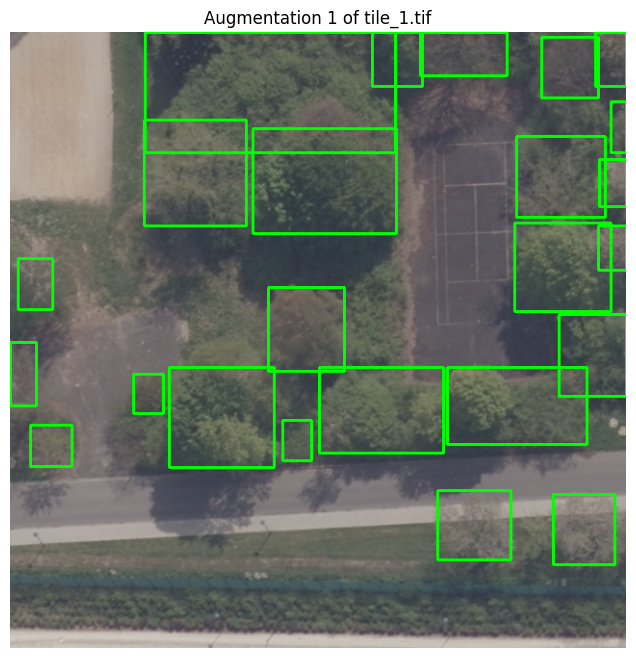

DEBUG: Processing bbox [31.875, 400.625, 81.25, 457.5] (type: <class 'list'>)
DEBUG: Processing bbox [115.625, 397.5, 175.625, 453.75] (type: <class 'list'>)
DEBUG: Processing bbox [308.125, 296.875, 393.125, 378.75] (type: <class 'list'>)
DEBUG: Processing bbox [471.875, 344.375, 505.625, 377.5] (type: <class 'list'>)
DEBUG: Processing bbox [580.0, 339.375, 596.875, 374.375] (type: <class 'list'>)
DEBUG: Processing bbox [277.5, 340.0, 301.25, 373.125] (type: <class 'list'>)
DEBUG: Processing bbox [170.625, 297.5, 271.25, 366.875] (type: <class 'list'>)
DEBUG: Processing bbox [542.5, 304.375, 585.0, 365.625] (type: <class 'list'>)
DEBUG: Processing bbox [54.375, 296.875, 167.5, 359.375] (type: <class 'list'>)
DEBUG: Processing bbox [398.125, 302.5, 421.875, 334.375] (type: <class 'list'>)
DEBUG: Processing bbox [501.25, 276.875, 549.375, 328.125] (type: <class 'list'>)
DEBUG: Processing bbox [7.5, 254.375, 76.875, 320.625] (type: <class 'list'>)
DEBUG: Processing bbox [0.0, 278.125, 5.

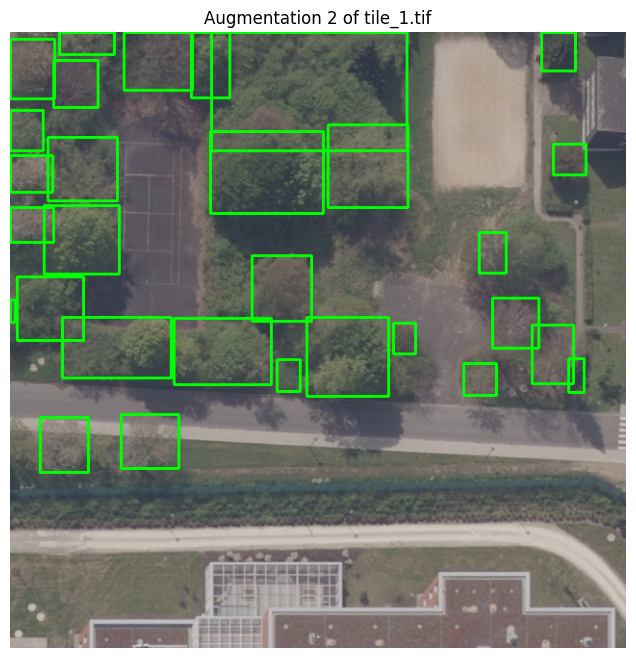

DEBUG: Processing bbox [606.4, 413.6, 640.0, 486.4] (type: <class 'list'>)
DEBUG: Processing bbox [485.6, 409.6, 562.4, 481.59999999999997] (type: <class 'list'>)
DEBUG: Processing bbox [207.2, 280.79999999999995, 316.0, 385.6] (type: <class 'list'>)
DEBUG: Processing bbox [63.2, 341.6, 106.4, 384.0] (type: <class 'list'>)
DEBUG: Processing bbox [324.79999999999995, 336.0, 355.20000000000005, 378.4] (type: <class 'list'>)
DEBUG: Processing bbox [363.2, 281.59999999999997, 492.0, 370.4] (type: <class 'list'>)
DEBUG: Processing bbox [0.0, 290.4, 16.0, 368.8] (type: <class 'list'>)
DEBUG: Processing bbox [496.0, 280.79999999999995, 640.0, 360.79999999999995] (type: <class 'list'>)
DEBUG: Processing bbox [170.39999999999998, 288.0, 200.79999999999998, 328.8] (type: <class 'list'>)
DEBUG: Processing bbox [7.199999999999999, 255.20000000000005, 68.8, 320.79999999999995] (type: <class 'list'>)
DEBUG: Processing bbox [612.0, 226.4, 640.0, 311.2] (type: <class 'list'>)
DEBUG: Processing bbox [3

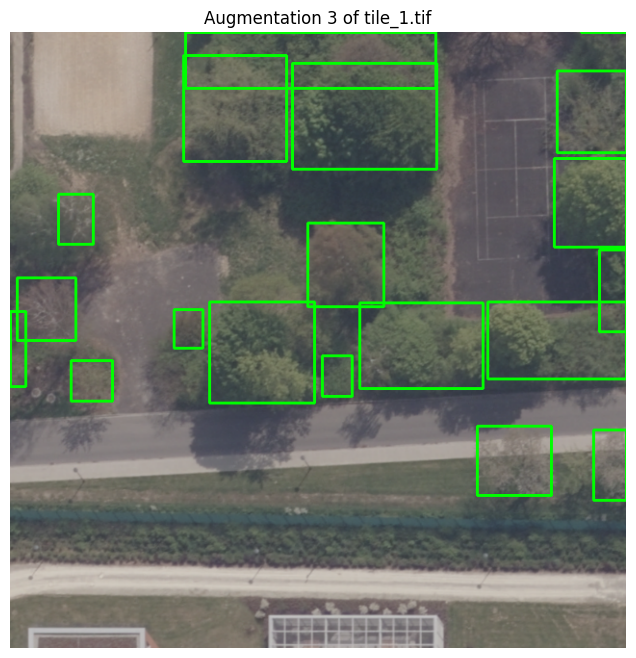

In [189]:
sample_idx = 0  # Choose an image index to visualize
for i in range(3):  # Show 3 different augmentations of the same image
    sample = train_dataset[sample_idx]
    img_path = sample['img_path']
    img_name = os.path.basename(img_path)
    visualize_sample(sample, f"Augmentation {i+1} of {img_name}")


In [190]:
def create_dataset_yaml(augment_factor = 50):
    # Create a directory for processed annotations if it doesn't exist
    os.makedirs('labels/train', exist_ok=True)
    os.makedirs('labels/val', exist_ok=True)
    os.makedirs('images/train', exist_ok=True)
    os.makedirs('images/val', exist_ok=True)
    dataset_augment = TreeDetectionDataset(train_image_files, train_mask_files, augment=True)
    dataset_normalize = TreeDetectionDataset(val_image_files, val_mask_files, augment=False)

    # Process training set masks and create annotation files
    for i, (img_path, mask_path) in enumerate(zip(train_image_files, train_mask_files)):
        # Get image and dimension
        img = cv2.imread(img_path)
        height, width = img.shape[:2]

        # Process mask
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
        processed_mask = dataset_augment.process_mask(mask)
        bboxes = dataset_augment.extract_bbox(processed_mask)

        # Convert to YOLO format
        yolo_bboxes = dataset_augment.convert_to_yolo_format(bboxes, width, height)

        # Write to annotation file
        img_name = os.path.basename(img_path)
        base_name = os.path.splitext(img_name)[0]
        with open(f'labels/train/{base_name}.txt', 'w') as f:
            for bbox in yolo_bboxes:
                f.write(f"{int(bbox[0])} {bbox[1]} {bbox[2]} {bbox[3]} {bbox[4]}\n")

        # Augmented images
        for aug_idx in range(1, augment_factor):
            if len(bboxes) > 0:
                # Set seed for reproducibility but different for each image
                np.random.seed(i * 1000 + aug_idx)

                transformed = dataset_augment.transform(
                    image=img,
                    bboxes=bboxes,
                    class_labels=[0] * len(bboxes)
                )

                aug_img = transformed['image']
                aug_bboxes = transformed['bboxes']

                # Generate augmented image filename
                aug_filename = f"{base_name}_aug{aug_idx}.tif"

                # Save augmented image
                cv2.imwrite(f'images/train/{aug_filename}', aug_img)

                # Convert bounding boxes to YOLO format
                h, w = aug_img.shape[:2]
                yolo_aug_bboxes = dataset_augment.convert_to_yolo_format(aug_bboxes, w, h)

                # Write annotation file for augmented image
                with open(f'labels/train/{base_name}_aug{aug_idx}.txt', 'w') as f:
                    for bbox in yolo_aug_bboxes:
                        f.write(f"{int(bbox[0])} {bbox[1]} {bbox[2]} {bbox[3]} {bbox[4]}\n")


    # Process validation set masks and create annotation files
    for i, (img_path, mask_path) in enumerate(zip(val_image_files, val_mask_files)):
        # Get image dimensions
        img = cv2.imread(img_path)
        height, width = img.shape[:2]

        # Process mask
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
        processed_mask = dataset_normalize.process_mask(mask)
        bboxes = dataset_normalize.extract_bbox(processed_mask)

        # Convert to YOLO format
        yolo_bboxes = dataset_normalize.convert_to_yolo_format(bboxes, width, height)

        # Write to annotation file
        img_name = os.path.basename(img_path)
        base_name = os.path.splitext(img_name)[0]
        with open(f'labels/val/{base_name}.txt', 'w') as f:
            for bbox in yolo_bboxes:
                f.write(f"{int(bbox[0])} {bbox[1]} {bbox[2]} {bbox[3]} {bbox[4]}\n")

        normalized = dataset_normalize.transform(
            image=img,
            bboxes=bboxes,
            class_labels=[0] * len(bboxes),
        )
        norm_img = normalized['image']
        norm_bboxes = normalized['bboxes']
        norm_filename = f"{base_name}.tif"
        cv2.imwrite(f'images/val/{norm_filename}', norm_img)
        h, w = norm_img.shape[:2]
        yolo_norm_bboxes = dataset_normalize.convert_to_yolo_format(norm_bboxes, w, h)

        with open(f'labels/val/{base_name}.txt', 'w') as f:
                    for bbox in yolo_norm_bboxes:
                        f.write(f"{int(bbox[0])} {bbox[1]} {bbox[2]} {bbox[3]} {bbox[4]}\n")

    # Create YAML file with proper directory structure
    dataset_yaml = {
        'path': os.path.abspath('.'),  # Current directory
        'train': 'images/train',  # These will be symbolic links or copied files
        'val': 'images/val',
        'names': {0: 'tree'},
        'nc': 1  # Number of classes
    }

    # Copy or link training images
    for img_path in train_image_files:
        img_name = os.path.basename(img_path)
        shutil.copy(img_path, f'images/train/{img_name}')


    # Copy or link validation images
    for img_path in val_image_files:
        img_name = os.path.basename(img_path)
        shutil.copy(img_path, f'images/val/{img_name}')


    with open('tree_dataset.yaml', 'w') as f:
        yaml.dump(dataset_yaml, f)

    return 'tree_dataset.yaml'

In [191]:
def train_with_ultralytics():
    # Create dataset config
    dataset_config = create_dataset_yaml()

    # Train the model
    model = YOLO("yolo11n.pt")  # Load a pretrained YOLOv8 nano model

    # Set up augmentation parameters in YOLO
    results = model.train(
        data=dataset_config,
        epochs=100,
        imgsz=640,
        batch=batch_size,
        workers=8,
        save=True,
        device='mps',
        patience=10,
        plots=True,
        augment=True,
    )

    return model, results

In [192]:
model, results = train_with_ultralytics()

DEBUG: Processing bbox [894, 292, 973, 383] (type: <class 'list'>)
DEBUG: Processing bbox [743, 298, 839, 388] (type: <class 'list'>)
DEBUG: Processing bbox [395, 418, 531, 549] (type: <class 'list'>)
DEBUG: Processing bbox [215, 420, 269, 473] (type: <class 'list'>)
DEBUG: Processing bbox [69, 425, 96, 481] (type: <class 'list'>)
DEBUG: Processing bbox [542, 427, 580, 480] (type: <class 'list'>)
DEBUG: Processing bbox [590, 437, 751, 548] (type: <class 'list'>)
DEBUG: Processing bbox [88, 439, 156, 537] (type: <class 'list'>)
DEBUG: Processing bbox [756, 449, 937, 549] (type: <class 'list'>)
DEBUG: Processing bbox [349, 489, 387, 540] (type: <class 'list'>)
DEBUG: Processing bbox [145, 499, 222, 581] (type: <class 'list'>)
DEBUG: Processing bbox [901, 511, 1012, 617] (type: <class 'list'>)
DEBUG: Processing bbox [1016, 542, 1024, 579] (type: <class 'list'>)
DEBUG: Processing bbox [523, 543, 622, 652] (type: <class 'list'>)
DEBUG: Processing bbox [843, 621, 968, 736] (type: <class 'lis

train: Scanning /Users/ygao/Documents/alexandria/RUG/forestry/notebooks/labels/train... 1600 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1600/1600 [00:00<00:00, 2676.57it/s]

train: New cache created: /Users/ygao/Documents/alexandria/RUG/forestry/notebooks/labels/train.cache


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /Users/ygao/Documents/alexandria/RUG/forestry/notebooks/labels/val.cache... 3 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3/3 [00:00<?, ?it/s]

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:19<00:00, 19.62s/it]

                   all          3         89      0.429      0.253       0.24      0.136



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     12/100        21G      1.342     0.9706      1.165        779        640:  35%|███▌      | 35/100 [15:35<28:58, 26.74s/it]


KeyboardInterrupt: 

In [193]:
predictions = model.predict(test_image_files)



WARNING ⚠️ NMS time limit 2.150s exceeded
0: 640x640 78 trees, 54807.8ms
1: 640x640 (no detections), 54807.8ms
2: 640x640 (no detections), 54807.8ms
Speed: 114.7ms preprocess, 54807.8ms inference, 3478.0ms postprocess per image at shape (1, 3, 640, 640)


In [24]:
model_10 = YOLO("runs/detect/train10/weights/best.pt")

prediction_val = model_10.predict(test_image_files, conf=0.60)


0: 640x640 19 trees, 44.3ms
1: 640x640 21 trees, 44.3ms
2: 640x640 14 trees, 44.3ms
Speed: 2.1ms preprocess, 44.3ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


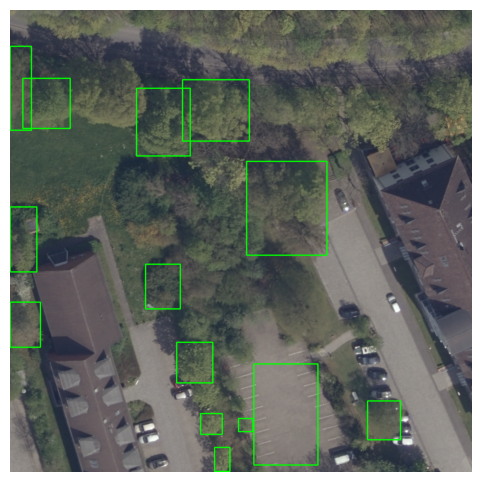

In [25]:
def visualize_prediction(img_path, result):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for visualization

    h, w = img.shape[:2]

    # Draw bounding boxes
    for box in result.boxes.xyxy:
        x_min, y_min, x_max, y_max = map(int, box[:4])  # Convert to integer pixel values
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)  # Green Box

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# Visualize the first image
visualize_prediction(test_image_files[2], prediction_val[2])